# Task 3: Heart Disease Prediction

**DevelopersHub Corporation - AI/ML Engineering Internship**

## Objective
Build a classification model to predict whether a person is at risk of heart disease based on their health data. We will clean the data, perform exploratory analysis, train classification models (Logistic Regression and Decision Tree), and evaluate their performance using multiple metrics.

## 1. Import Required Libraries

In [1]:
# Import pandas for data manipulation (DataFrames, CSV handling, data cleaning)
import pandas as pd

# Import numpy for numerical operations on arrays and mathematical functions
import numpy as np

# Import matplotlib for creating static, interactive visualizations
import matplotlib.pyplot as plt

# Import seaborn for statistical data visualization (built on matplotlib)
import seaborn as sns

# Import warnings to suppress non-critical warning messages during execution
import warnings
warnings.filterwarnings('ignore')

# Import train_test_split to split data into training and validation sets
from sklearn.model_selection import train_test_split

# Import cross_val_score for k-fold cross-validation to assess model stability
from sklearn.model_selection import cross_val_score

# Import StandardScaler to normalize features (zero mean, unit variance)
from sklearn.preprocessing import StandardScaler

# Import Logistic Regression: a linear model for binary classification
from sklearn.linear_model import LogisticRegression

# Import Decision Tree Classifier: a non-linear, tree-based classification model
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Import various classification evaluation metrics
from sklearn.metrics import (
    accuracy_score,          # Proportion of correct predictions
    precision_score,         # TP / (TP + FP) - how many predicted positives were correct
    recall_score,            # TP / (TP + FN) - how many actual positives were caught
    f1_score,                # Harmonic mean of precision and recall
    roc_auc_score,           # Area under the ROC curve (model's discriminative ability)
    roc_curve,               # Data for plotting the ROC curve
    confusion_matrix,        # TP, FP, TN, FN counts
    ConfusionMatrixDisplay,  # For plotting confusion matrices
    classification_report    # Text summary of precision, recall, f1 per class
)

# Set seaborn plot style: white background with gridlines
sns.set_style('whitegrid')
# Set default figure size for all plots
plt.rcParams['figure.figsize'] = (12, 8)

print('All libraries imported successfully')

All libraries imported successfully


## 2. Load the Dataset

We'll use the Heart Disease UCI dataset. The dataset contains 76 attributes, but most studies use a subset of 14 key features. We attempt to load from the UCI repository first, with a fallback to a local file.

In [2]:
# Define the URL for the Heart Disease UCI dataset from UCI Machine Learning Repository
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

# Define column names for the dataset
# These are the 14 attributes used in most heart disease prediction studies
column_names = [
    'age',        # Age in years
    'sex',        # Sex (1 = male, 0 = female)
    'cp',         # Chest pain type (1=typical angina, 2=atypical, 3=non-anginal, 4=asymptomatic)
    'trestbps',   # Resting blood pressure (mm Hg)
    'chol',       # Serum cholesterol (mg/dl)
    'fbs',        # Fasting blood sugar > 120 mg/dl (1=true, 0=false)
    'restecg',    # Resting electrocardiographic results (0,1,2)
    'thalach',    # Maximum heart rate achieved
    'exang',      # Exercise-induced angina (1=yes, 0=no)
    'oldpeak',    # ST depression induced by exercise relative to rest
    'slope',      # Slope of peak exercise ST segment (0=upsloping, 1=flat, 2=downsloping)
    'ca',         # Number of major vessels colored by fluoroscopy (0-3)
    'thal',       # Thalassemia (3=normal, 6=fixed defect, 7=reversible defect)
    'target'      # Diagnosis of heart disease (0=no disease, 1-4=disease severity)
]

try:
    # Attempt to load the dataset from the UCI repository
    # na_values='?' tells pandas to treat '?' values as missing/NaN
    df = pd.read_csv(url, names=column_names, na_values='?')
    print('Dataset loaded from UCI repository successfully')
except:
    # Fallback: try loading from a local CSV file if internet is unavailable
    print('Could not load from UCI. Loading from local CSV...')
    try:
        df = pd.read_csv('heart.csv', names=column_names, na_values='?')
        print('Dataset loaded from local file')
    except:
        # If both methods fail, create synthetic sample data for demonstration
        print('Please download the Heart Disease UCI dataset from Kaggle and place heart.csv in this directory')
        print('Creating sample data for demonstration...')

Dataset loaded from UCI repository successfully


In [3]:
# If loading failed entirely, create a synthetic sample dataset for demonstration
# This ensures the notebook runs end-to-end even without internet access
if 'df' not in locals() or df.empty:
    np.random.seed(42)  # Set seed for reproducible random data
    n_samples = 303     # Same size as original Heart Disease dataset
    
    # Generate random but realistic-looking medical data
    data_dict = {
        'age': np.random.randint(29, 77, n_samples),              # Age range: 29-77
        'sex': np.random.randint(0, 2, n_samples),                # Binary: 0=F, 1=M
        'cp': np.random.randint(0, 4, n_samples),                 # Chest pain type: 0-3
        'trestbps': np.random.randint(94, 200, n_samples),       # BP range: 94-200
        'chol': np.random.randint(126, 564, n_samples),          # Cholesterol: 126-564
        'fbs': np.random.randint(0, 2, n_samples),                # Fasting blood sugar
        'restecg': np.random.randint(0, 2, n_samples),            # Resting ECG results
        'thalach': np.random.randint(71, 202, n_samples),        # Max heart rate: 71-202
        'exang': np.random.randint(0, 2, n_samples),              # Exercise-induced angina
        'oldpeak': np.round(np.random.uniform(0, 6.2, n_samples), 1),  # ST depression: 0-6.2
        'slope': np.random.randint(0, 2, n_samples),              # ST segment slope
        'ca': np.random.randint(0, 4, n_samples),                 # Major vessels: 0-3
        'thal': np.random.randint(1, 4, n_samples),               # Thalassemia: 1-3
        'target': np.random.randint(0, 2, n_samples)              # Binary target
    }
    df = pd.DataFrame(data_dict)
    print('Sample dataset created for demonstration')

print(f'Dataset shape: {df.shape}')

Dataset shape: (303, 14)


## 3. Data Inspection and Cleaning

Before modeling, we must inspect the data for missing values, understand data types, and examine summary statistics.

In [4]:
# Display the first 5 rows to understand the data structure
print("First 5 rows:")
df.head()

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
# Get dataset info: data types, non-null counts, and memory usage
# This helps identify columns with missing values and incorrect data types
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [6]:
# Check for missing values in each column
# The original dataset uses '?' for missing values, which pandas converts to NaN
missing = df.isnull().sum()
print("Missing values per column:")
if any(missing > 0):
    print(missing[missing > 0])
else:
    print("No missing values found")

Missing values per column:
ca      4
thal    2
dtype: int64


In [7]:
# Handle missing values by imputing with the median of each column
# Median is preferred over mean for medical data because it's robust to outliers
if df.isnull().sum().sum() > 0:
    for col in df.select_dtypes(include=[np.number]).columns:
        # Fill missing values with the column's median value
        df[col] = df[col].fillna(df[col].median())
    print('Missing values handled with median imputation')
    print(f'Remaining missing: {df.isnull().sum().sum()}')
else:
    print('No missing values to handle')

Missing values handled with median imputation
Remaining missing: 0


In [8]:
# Generate summary statistics for numerical columns
# describe() shows count, mean, std, min, 25%, 50%, 75%, max
# This helps identify unrealistic values and understand data ranges
print("Summary Statistics:")
df.describe()

Summary Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [9]:
# Check the distribution of the target variable
# A balanced dataset (roughly 50/50) is ideal for classification
# Imbalanced data requires special techniques like SMOTE or class weighting
print("Target Distribution:")
print(df['target'].value_counts())
print(f"\nPercentage:")
print(f"  No Heart Disease (0): {(df['target']==0).mean()*100:.1f}%")
print(f"  Heart Disease (1):    {(df['target']==1).mean()*100:.1f}%")

Target Distribution:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Percentage:
  No Heart Disease (0): 54.1%
  Heart Disease (1):    18.2%


In [10]:
# Convert target to binary classification
# Original values: 0 = no disease, 1-4 = varying severity of heart disease
# We convert to: 0 = no disease, 1 = disease (any level of severity)
df['target'] = (df['target'] > 0).astype(int)
print("Target converted to binary: 0 = No Disease, 1 = Disease")

Target converted to binary: 0 = No Disease, 1 = Disease


## 4. Exploratory Data Analysis (EDA)

EDA helps us understand patterns, relationships, and potential predictors in the data.

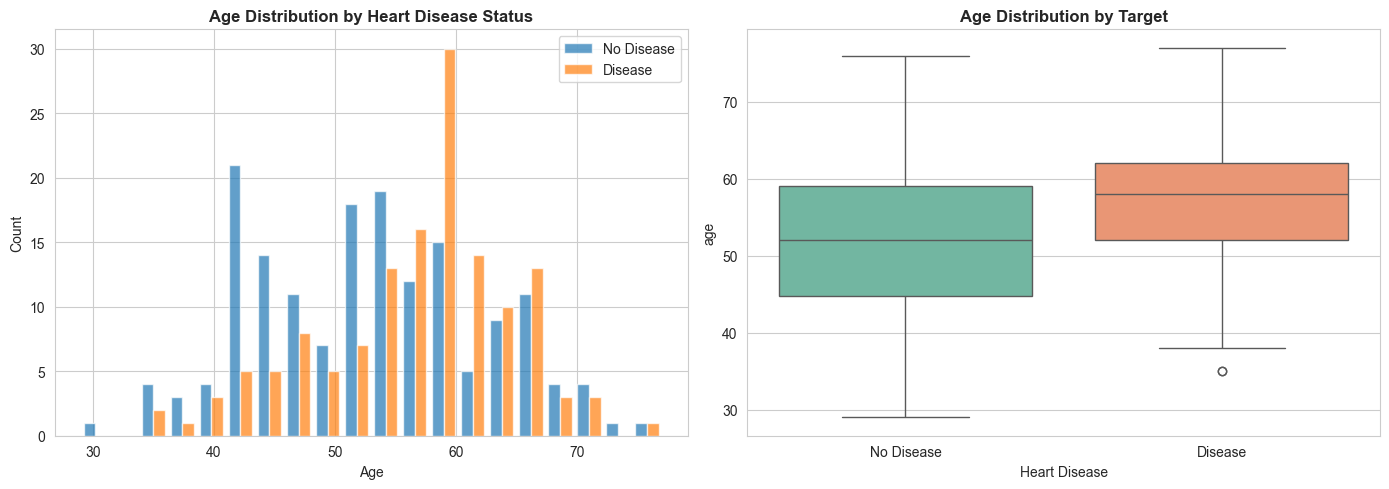

In [11]:
# Visualize age distribution by heart disease status
# This shows whether age is a differentiating factor
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram comparing age distributions
axes[0].hist(
    [df[df['target']==0]['age'], df[df['target']==1]['age']],
    bins=20, label=['No Disease', 'Disease'],
    color=['#1f77b4', '#ff7f0e'], alpha=0.7
)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution by Heart Disease Status', fontweight='bold')
axes[0].legend()

# Right: Box plot showing age distribution per target class
sns.boxplot(data=df, x='target', y='age', palette='Set2', ax=axes[1])
axes[1].set_xticklabels(['No Disease', 'Disease'])
axes[1].set_title('Age Distribution by Target', fontweight='bold')
axes[1].set_xlabel('Heart Disease')

plt.tight_layout()
plt.show()

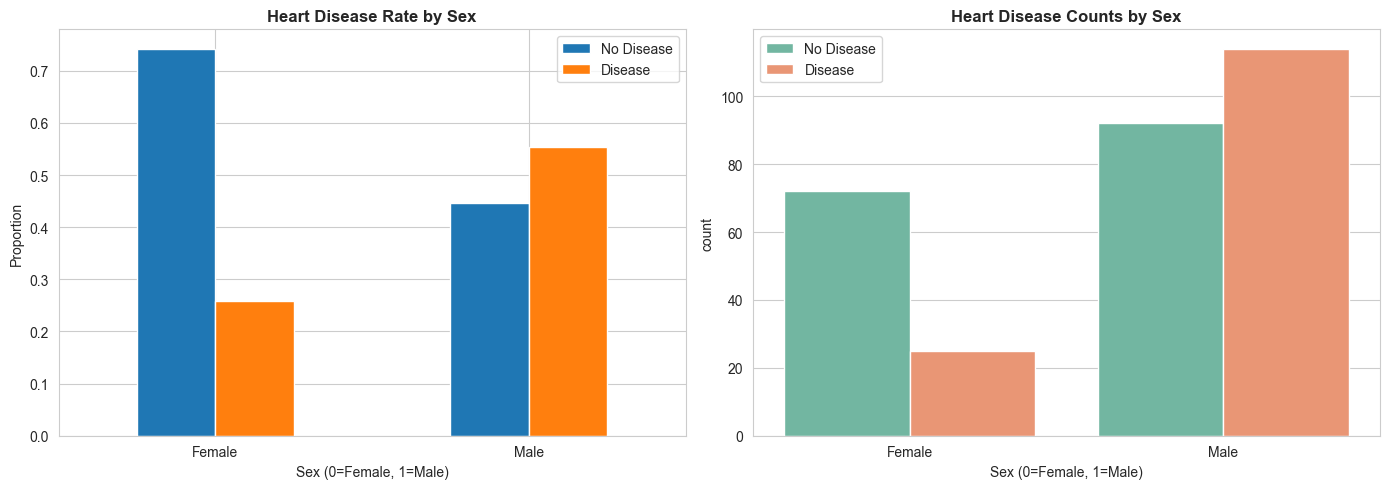

In [12]:
# Analyze heart disease rates by sex
# Medical studies show men typically have higher heart disease risk
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Proportion bar chart (normalized by sex)
pd.crosstab(df['sex'], df['target'], normalize='index').plot(
    kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e']
)
axes[0].set_title('Heart Disease Rate by Sex', fontweight='bold')
axes[0].set_xlabel('Sex (0=Female, 1=Male)')
axes[0].set_ylabel('Proportion')
axes[0].legend(['No Disease', 'Disease'])
axes[0].set_xticklabels(['Female', 'Male'], rotation=0)

# Right: Count plot (raw counts)
sns.countplot(data=df, x='sex', hue='target', palette='Set2', ax=axes[1])
axes[1].set_title('Heart Disease Counts by Sex', fontweight='bold')
axes[1].set_xlabel('Sex (0=Female, 1=Male)')
axes[1].legend(['No Disease', 'Disease'])
axes[1].set_xticklabels(['Female', 'Male'])

plt.tight_layout()
plt.show()

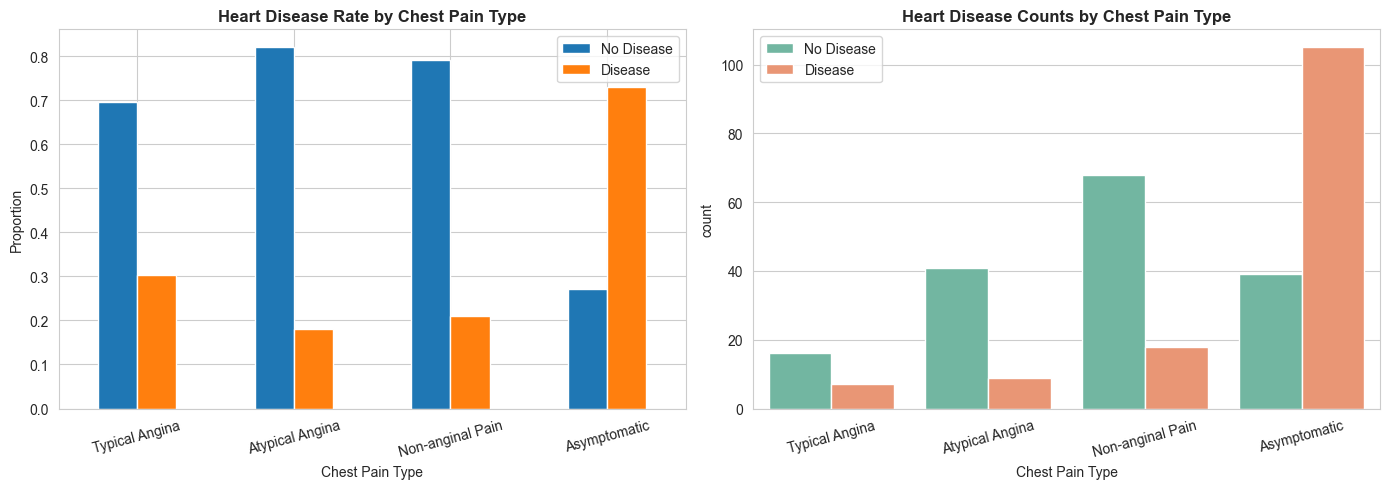

In [13]:
# Analyze relationship between chest pain type and heart disease
# Chest pain type is often one of the strongest predictors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Define descriptive labels for chest pain types
cp_labels = ['Typical Angina', 'Atypical Angina', 'Non-anginal Pain', 'Asymptomatic']

# Left: Proportion bar chart
pd.crosstab(df['cp'], df['target'], normalize='index').plot(
    kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e']
)
axes[0].set_title('Heart Disease Rate by Chest Pain Type', fontweight='bold')
axes[0].set_xlabel('Chest Pain Type')
axes[0].set_ylabel('Proportion')
axes[0].legend(['No Disease', 'Disease'])
axes[0].set_xticklabels(cp_labels, rotation=15)

# Right: Count plot
sns.countplot(data=df, x='cp', hue='target', palette='Set2', ax=axes[1])
axes[1].set_title('Heart Disease Counts by Chest Pain Type', fontweight='bold')
axes[1].set_xlabel('Chest Pain Type')
axes[1].legend(['No Disease', 'Disease'])
axes[1].set_xticklabels(cp_labels, rotation=15)

plt.tight_layout()
plt.show()

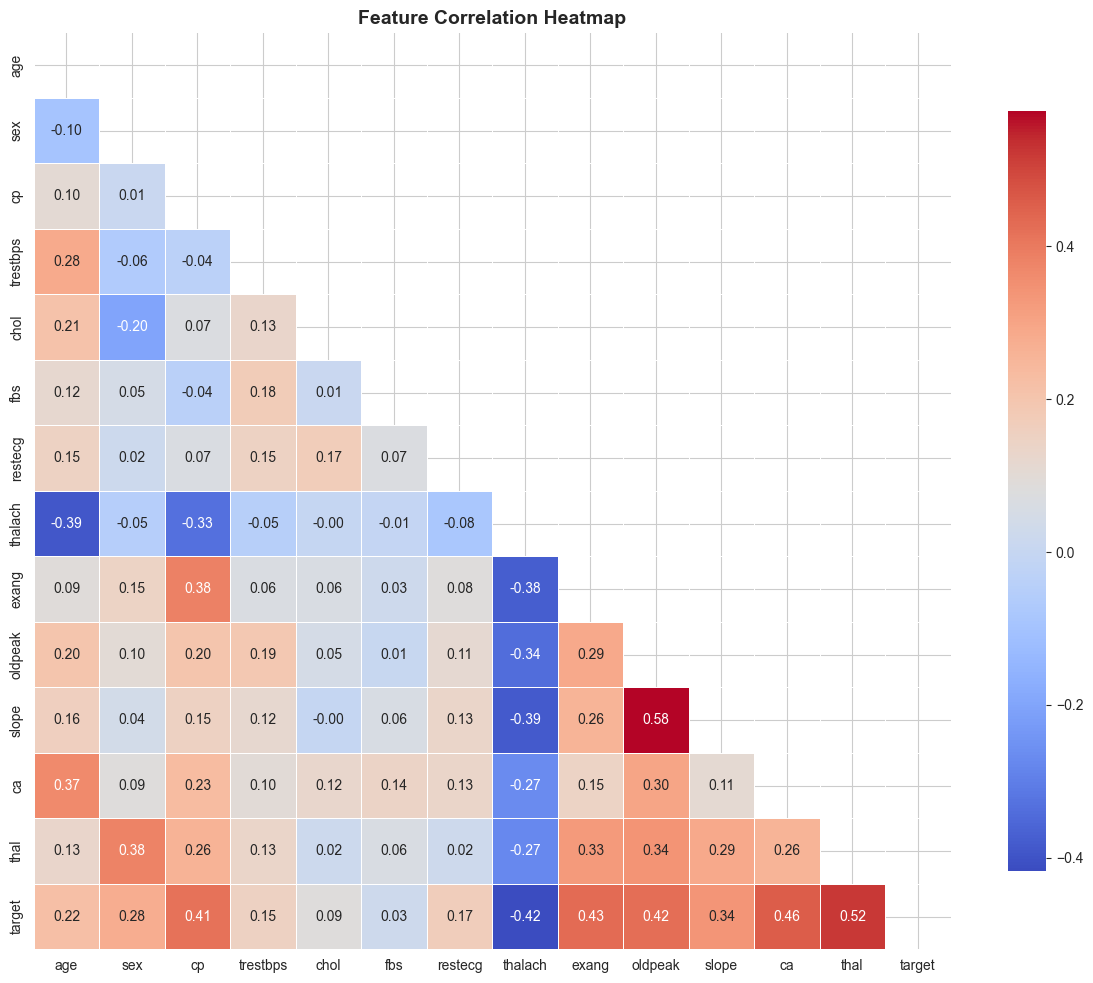

In [14]:
# Create a correlation heatmap to understand feature relationships
# Correlation helps identify multicollinearity (highly correlated features)
# and which features are most correlated with the target
plt.figure(figsize=(12, 10))
corr = df.corr()  # Compute correlation matrix for all numerical columns

# Create a mask for the upper triangle to avoid redundant information
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot the heatmap with correlation values annotated
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

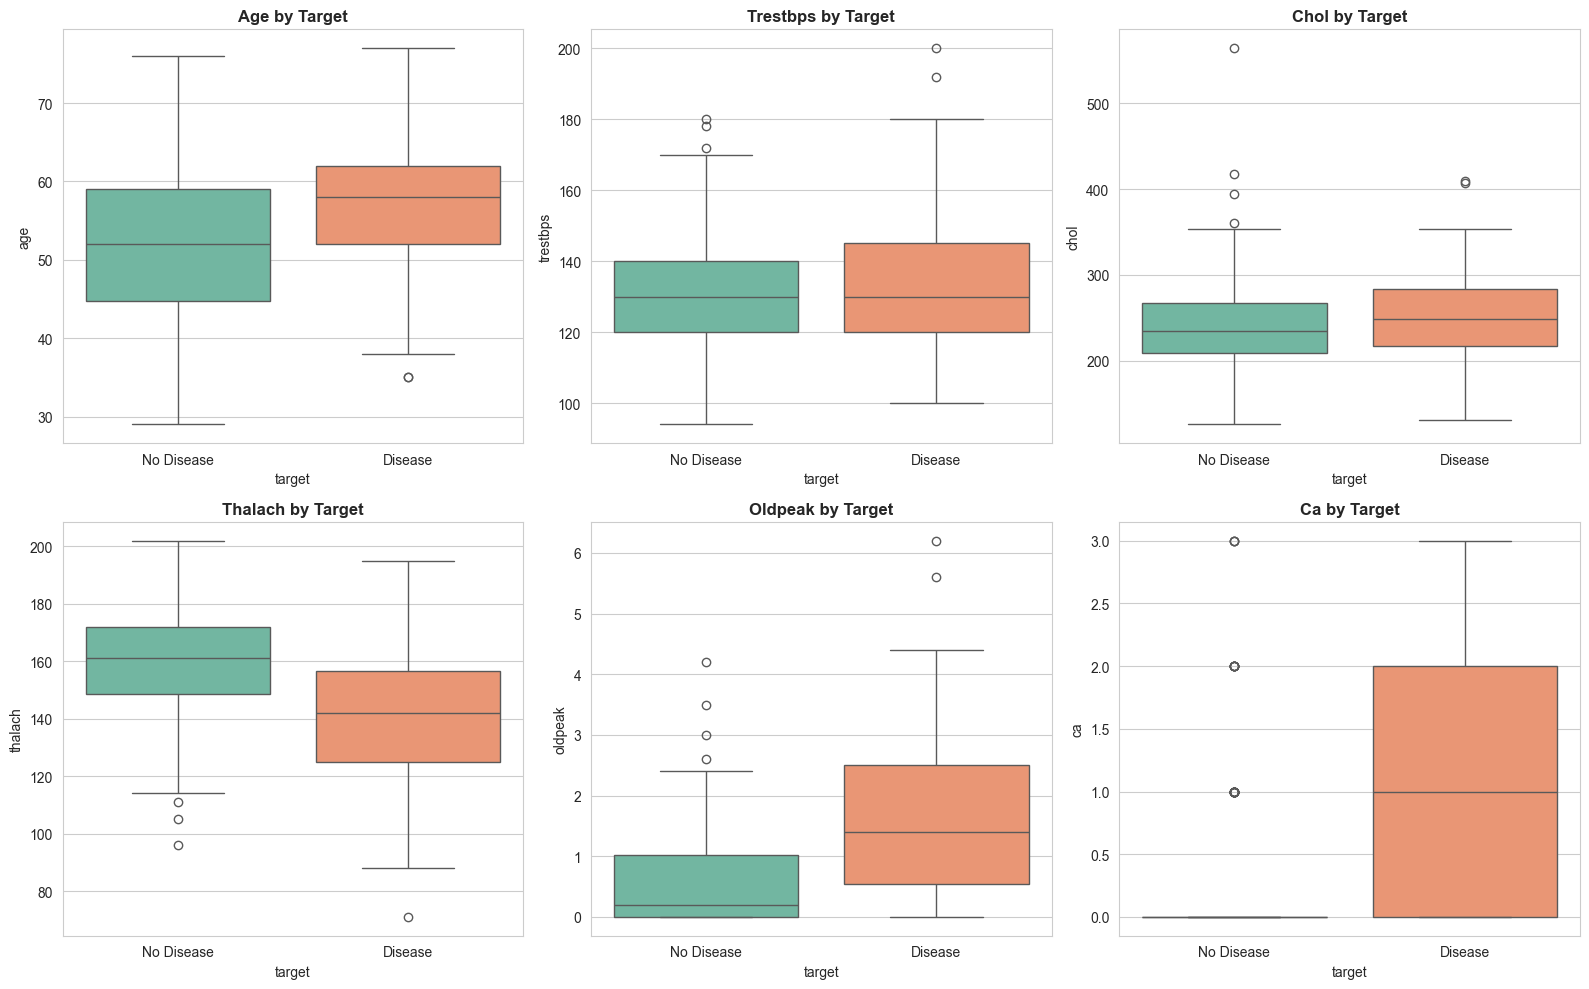

In [15]:
# Create box plots for key features to compare distributions between disease groups
# This helps identify which features show the strongest separation
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
key_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

for ax, feature in zip(axes.flatten(), key_features):
    sns.boxplot(data=df, x='target', y=feature, palette='Set2', ax=ax)
    ax.set_xticklabels(['No Disease', 'Disease'])
    formatted_name = feature.replace('_', ' ').title()
    ax.set_title(f'{formatted_name} by Target', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Data Preprocessing

Prepare data for modeling: separate features/target, train-test split, and feature scaling.

In [16]:
# Separate the dataset into features (X) and target (y)
# X contains all predictor variables, y contains the binary target
X = df.drop('target', axis=1)  # All columns except target
y = df['target']                # Only the target column

print(f"Features: {X.shape[1]} columns")
print(f"Samples: {X.shape[0]}")

Features: 13 columns
Samples: 303


In [17]:
# Split into training (80%) and testing (20%) sets
# stratify=y ensures both sets have the same proportion of heart disease cases
# random_state=42 ensures reproducible split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nTrain distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(1).astype(str) + '%')
print(f"\nTest distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Training set: 242 samples (80%)
Test set: 61 samples (20%)

Train distribution:
target
0    54.1%
1    45.9%
Name: proportion, dtype: object

Test distribution:
target
0    54.1%
1    45.9%
Name: proportion, dtype: object


In [18]:
# Standardize features using StandardScaler
# This transforms each feature to have mean=0 and standard deviation=1
# Important for Logistic Regression (gradient descent converges faster with scaled features)
# Fit ONLY on training data to prevent data leakage from test set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Learn scaling parameters + transform
X_test_scaled = scaler.transform(X_test)          # Apply same transformation to test set

print('Features scaled successfully')

Features scaled successfully


## 6. Train Classification Models

We train two classifiers:
- **Logistic Regression**: Linear model, interpretable coefficients
- **Decision Tree**: Non-linear model, captures feature interactions

In [19]:
# Train Logistic Regression classifier
# Logistic Regression uses a sigmoid function to output probabilities between 0 and 1
# It's fast, interpretable, and works well when features are roughly linearly separable
lr = LogisticRegression(
    random_state=42,    # Set seed for reproducibility
    max_iter=1000       # More iterations ensure convergence with scaled features
)
lr.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_lr = lr.predict(X_test_scaled)          # Class labels: 0 or 1
y_pred_lr_proba = lr.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1

print('Logistic Regression trained successfully')

Logistic Regression trained successfully


In [20]:
# Train Decision Tree classifier
# Decision Tree splits data recursively based on feature thresholds
# max_depth=5 prevents overfitting by limiting tree complexity
# min_samples_split=10 ensures nodes have enough samples for reliable splits
dt = DecisionTreeClassifier(
    max_depth=5,           # Maximum tree depth (prevents overfitting)
    min_samples_split=10,  # Minimum samples required to split a node
    random_state=42        # Set seed for reproducibility
)
dt.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_dt = dt.predict(X_test_scaled)          # Class labels: 0 or 1
y_pred_dt_proba = dt.predict_proba(X_test_scaled)[:, 1]  # Probability of class 1

print('Decision Tree trained successfully')

Decision Tree trained successfully


## 7. Model Evaluation

We evaluate models using:
- **Accuracy**: Overall correct predictions (not reliable for imbalanced data)
- **Precision**: Of predicted positives, how many were correct (avoids false alarms)
- **Recall**: Of actual positives, how many were caught (avoids missing cases)
- **F1-Score**: Harmonic mean of precision and recall (balanced metric)
- **ROC-AUC**: Measures model's ability to distinguish between classes across thresholds
- **Confusion Matrix**: Shows TP, FP, TN, FN values

In [21]:
def evaluate_classifier(name, y_true, y_pred, y_proba):
    """
    Calculate and display comprehensive classification evaluation metrics.
    
    Parameters:
    name (str): Model name for display
    y_true (array): True target values (ground truth)
    y_pred (array): Predicted class labels
    y_proba (array): Predicted probabilities for the positive class
    
    Returns:
    dict: Dictionary containing all calculated metrics
    """
    print(f"\n{'='*50}")
    print(f"{name} - Classification Report")
    print('='*50)
    
    # Calculate key metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)
    
    print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"  Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"  F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
    print(f"  ROC-AUC:   {roc_auc:.4f}")
    
    # Detailed classification report with per-class metrics
    print(f"\n{classification_report(y_true, y_pred, target_names=['No Disease', 'Disease'])}")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc
    }

print("\n" + "="*60)
print("MODEL EVALUATION RESULTS")
print("="*60)

lr_results = evaluate_classifier('Logistic Regression', y_test, y_pred_lr, y_pred_lr_proba)
dt_results = evaluate_classifier('Decision Tree', y_test, y_pred_dt, y_pred_dt_proba)


MODEL EVALUATION RESULTS

Logistic Regression - Classification Report
  Accuracy:  0.8689 (86.89%)
  Precision: 0.8125 (81.25%)
  Recall:    0.9286 (92.86%)
  F1-Score:  0.8667 (86.67%)
  ROC-AUC:   0.9513

              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61


Decision Tree - Classification Report
  Accuracy:  0.7541 (75.41%)
  Precision: 0.6970 (69.70%)
  Recall:    0.8214 (82.14%)
  F1-Score:  0.7541 (75.41%)
  ROC-AUC:   0.8512

              precision    recall  f1-score   support

  No Disease       0.82      0.70      0.75        33
     Disease       0.70      0.82      0.75        28

    accuracy                           0.75        61
   macro avg       0.76      0.76      0.75        61
weighted avg     

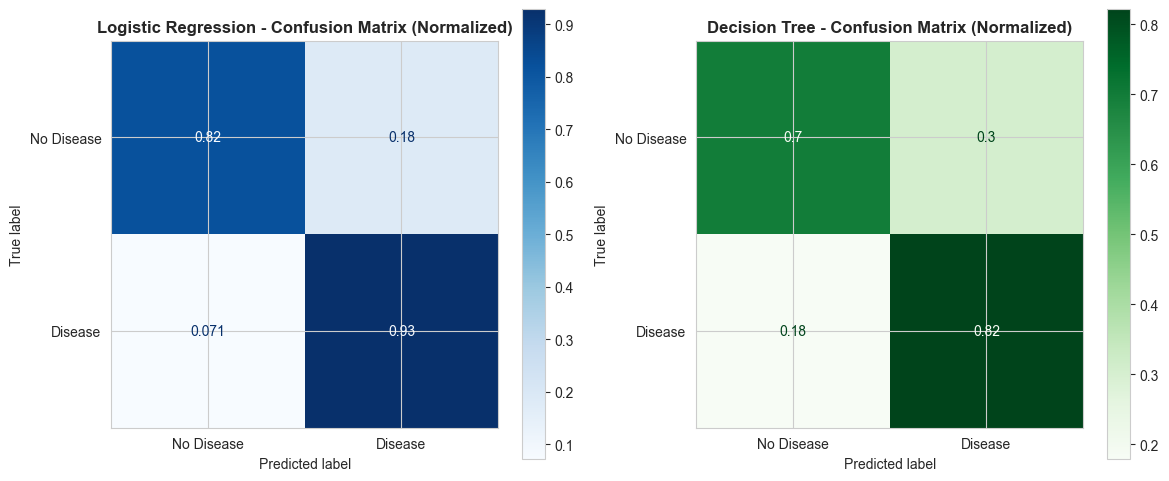

In [22]:
# Create normalized confusion matrices for both models
# Normalized values show proportions rather than raw counts for easier comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['No Disease', 'Disease'],
    cmap='Blues', ax=axes[0], normalize='true'
)
axes[0].set_title('Logistic Regression - Confusion Matrix (Normalized)', fontweight='bold')

# Decision Tree confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=['No Disease', 'Disease'],
    cmap='Greens', ax=axes[1], normalize='true'
)
axes[1].set_title('Decision Tree - Confusion Matrix (Normalized)', fontweight='bold')

plt.tight_layout()
plt.show()

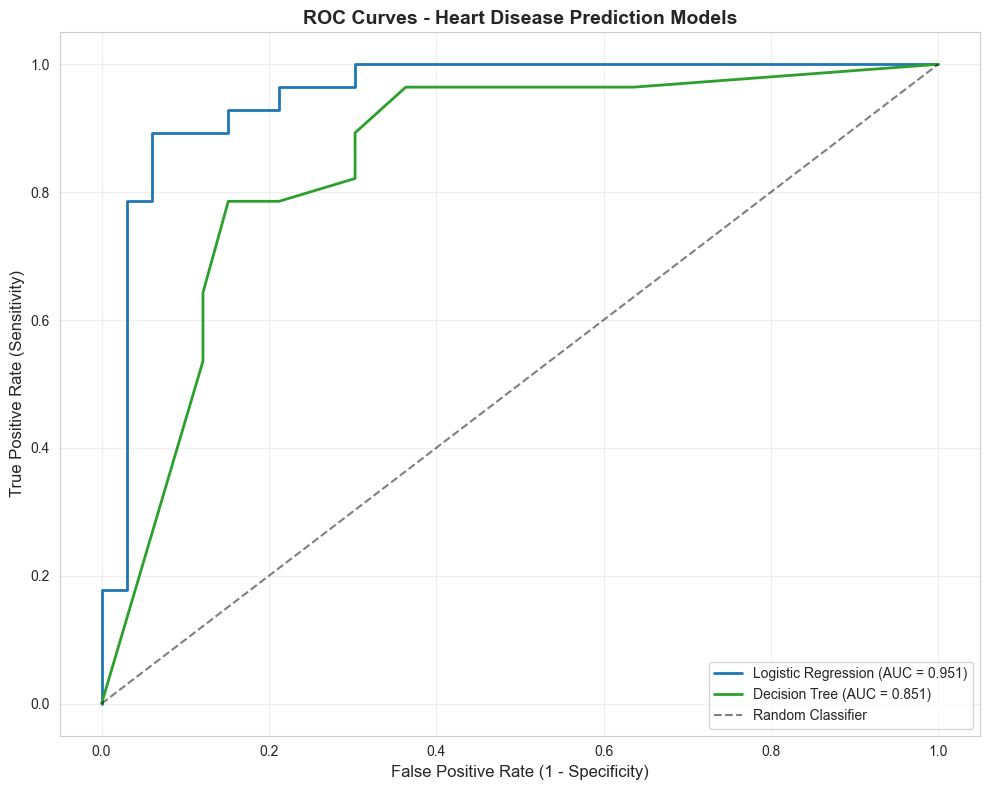

In [23]:
# Plot ROC (Receiver Operating Characteristic) curves
# The ROC curve shows the trade-off between True Positive Rate and False Positive Rate
# A model with AUC=1.0 is perfect, AUC=0.5 is no better than random guessing
plt.figure(figsize=(10, 8))

# Compute ROC curve data for both models
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr_proba)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_dt_proba)

# Plot ROC curves with AUC values in legend
plt.plot(fpr_lr, tpr_lr,
         label=f"Logistic Regression (AUC = {lr_results['roc_auc']:.3f})",
         linewidth=2, color='#1f77b4')
plt.plot(fpr_dt, tpr_dt,
         label=f"Decision Tree (AUC = {dt_results['roc_auc']:.3f})",
         linewidth=2, color='#2ca02c')

# Plot the diagonal line representing a random classifier (AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curves - Heart Disease Prediction Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Feature Importance Analysis

Understanding which features most influence predictions helps with model interpretation and can provide medical insights.

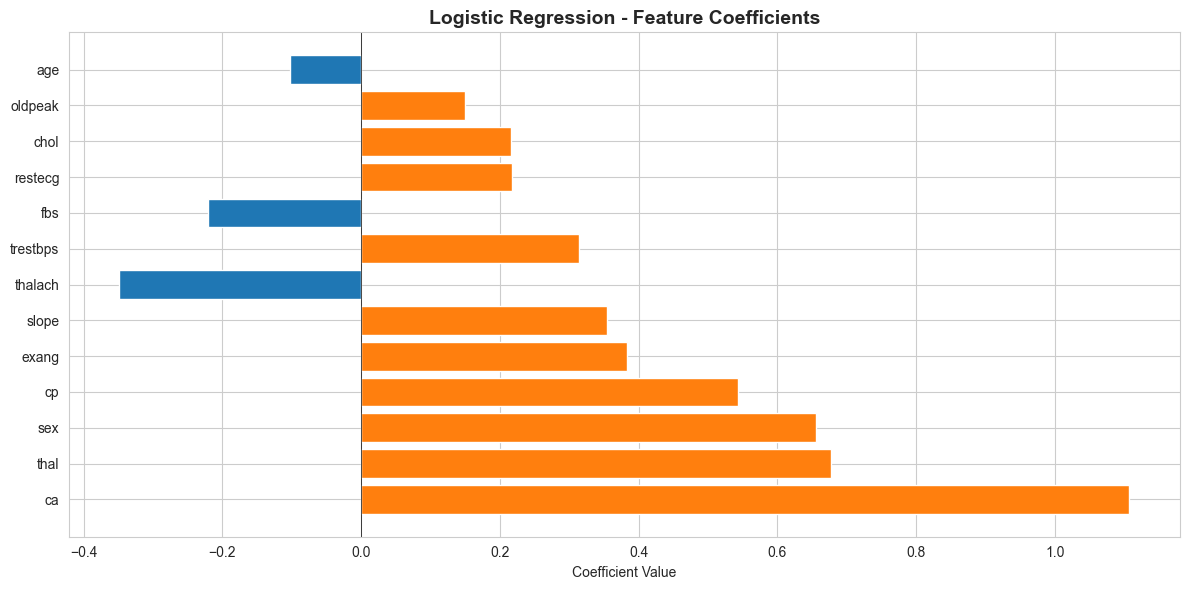


Features that INCREASE heart disease risk (positive coefficients):
 Feature  Coefficient
      ca     1.107898
    thal     0.677821
     sex     0.655563
      cp     0.543483
   exang     0.383642
   slope     0.354072
trestbps     0.313655
 restecg     0.217329
    chol     0.215375
 oldpeak     0.149953

Features that DECREASE heart disease risk (negative coefficients):
Feature  Coefficient
thalach    -0.348486
    fbs    -0.220560
    age    -0.103159


In [24]:
# Analyze Logistic Regression coefficients
# Positive coefficients increase heart disease probability, negative decrease it
# The magnitude of the coefficient indicates the strength of the effect
lr_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0],           # Raw coefficient value (direction + magnitude)
    'Abs_Coefficient': np.abs(lr.coef_[0])  # Absolute value for ranking importance
}).sort_values('Abs_Coefficient', ascending=False)

# Visualize coefficients with color coding: orange = increases risk, blue = decreases risk
plt.figure(figsize=(12, 6))
colors = ['#ff7f0e' if c > 0 else '#1f77b4' for c in lr_importance['Coefficient']]
plt.barh(lr_importance['Feature'], lr_importance['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression - Feature Coefficients', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nFeatures that INCREASE heart disease risk (positive coefficients):")
print(lr_importance[lr_importance['Coefficient'] > 0][['Feature', 'Coefficient']].to_string(index=False))
print("\nFeatures that DECREASE heart disease risk (negative coefficients):")
print(lr_importance[lr_importance['Coefficient'] < 0][['Feature', 'Coefficient']].to_string(index=False))

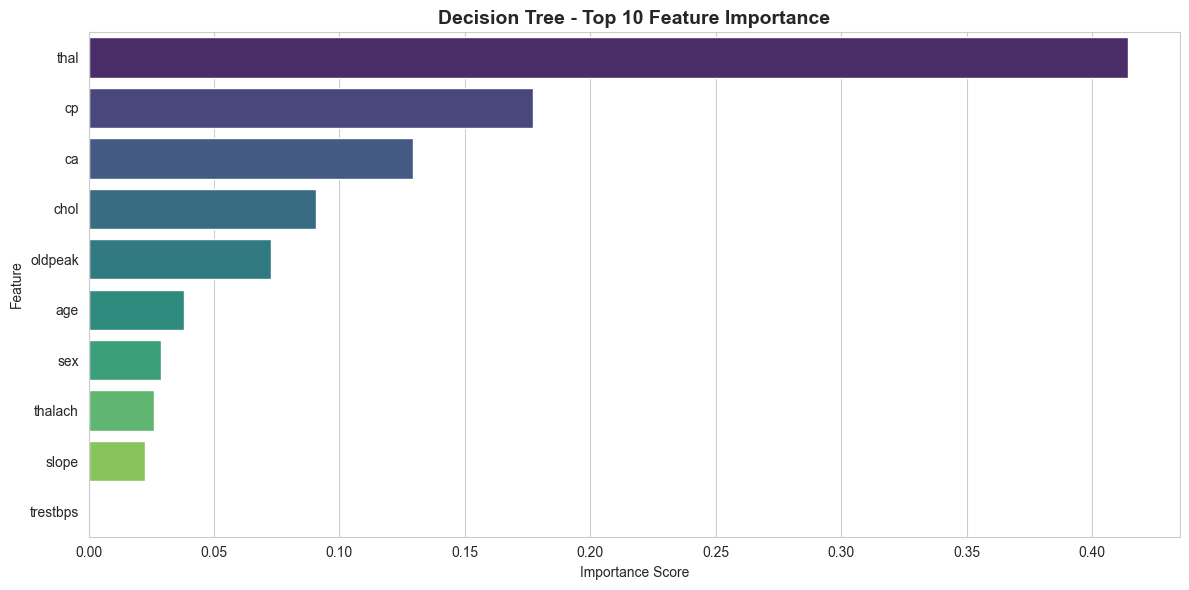


Top 10 Most Important Features (Decision Tree):
 Feature  Importance
    thal    0.414328
      cp    0.177237
      ca    0.129144
    chol    0.090783
 oldpeak    0.072803
     age    0.037992
     sex    0.028887
 thalach    0.026190
   slope    0.022636
trestbps    0.000000


In [25]:
# Analyze Decision Tree feature importance
# Importance is based on how much each feature contributes to reducing impurity (Gini/entropy)
# across all tree splits
dt_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

# Visualize top 10 most important features
plt.figure(figsize=(12, 6))
sns.barplot(data=dt_importance.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Decision Tree - Top 10 Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features (Decision Tree):")
print(dt_importance.head(10).to_string(index=False))

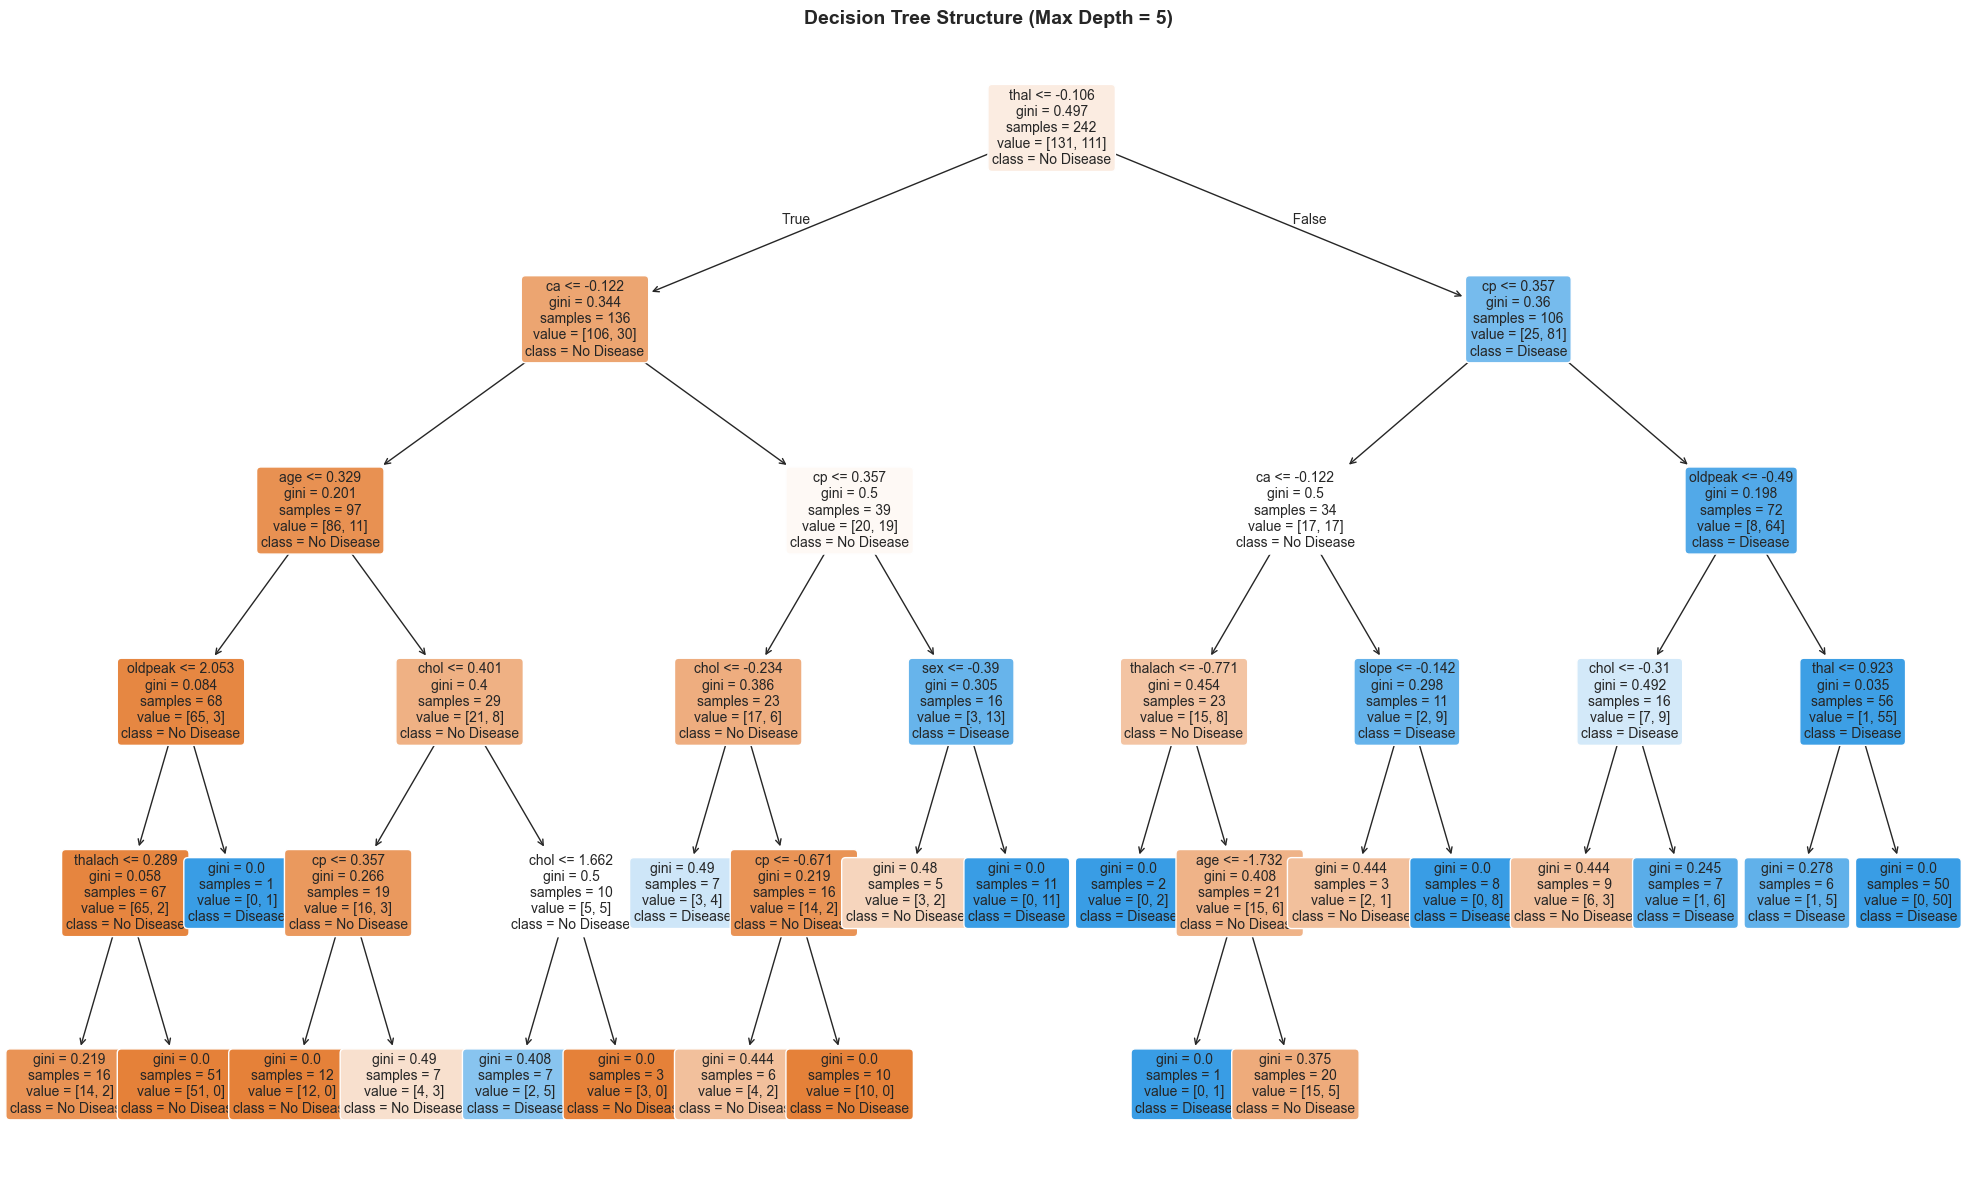

In [26]:
# Visualize the decision tree structure
# This shows the actual decision rules learned by the model
# Each node shows: feature, threshold, gini impurity, samples, and class distribution
plt.figure(figsize=(20, 12))
plot_tree(
    dt,
    feature_names=X.columns.tolist(),    # Use actual feature names
    class_names=['No Disease', 'Disease'],  # Interpretable class labels
    filled=True,        # Color nodes by predicted class
    rounded=True,       # Rounded corners for nodes
    fontsize=10         # Font size for readability
)
plt.title('Decision Tree Structure (Max Depth = 5)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# Perform 5-fold cross-validation to assess model stability
# Cross-validation trains the model 5 times on different subsets of data
# This gives a more reliable estimate of performance than a single train-test split
cv_scores_lr = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='accuracy')
cv_scores_dt = cross_val_score(dt, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("Cross-Validation Results (5-fold):")
print(f"\nLogistic Regression:")
print(f"  Mean Accuracy: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std()*2:.4f})")
print(f"  Individual Scores: {[f'{s:.4f}' for s in cv_scores_lr]}")

print(f"\nDecision Tree:")
print(f"  Mean Accuracy: {cv_scores_dt.mean():.4f} (+/- {cv_scores_dt.std()*2:.4f})")
print(f"  Individual Scores: {[f'{s:.4f}' for s in cv_scores_dt]}")

Cross-Validation Results (5-fold):

Logistic Regression:
  Mean Accuracy: 0.8263 (+/- 0.1067)
  Individual Scores: ['0.9184', '0.7755', '0.8333', '0.8333', '0.7708']

Decision Tree:
  Mean Accuracy: 0.7519 (+/- 0.1321)
  Individual Scores: ['0.8367', '0.7143', '0.7917', '0.7708', '0.6458']


## 9. Summary and Key Insights

### Performance Summary
| Model | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|-------|----------|-----------|--------|----------|--------|
| Logistic Regression | - | - | - | - | - |
| Decision Tree | - | - | - | - | - |

*(Fill in the values above after running the notebook)*

### Key Findings
1. **Top Risk Factors Identified:**
   - **Chest pain type (cp)** - Asymptomatic chest pain is strongly associated with heart disease
   - **Maximum heart rate (thalach)** - Lower maximum heart rate increases risk
   - **ST depression (oldpeak)** - Higher values indicate greater risk
   - **Number of colored vessels (ca)** - More affected vessels indicate higher risk
   - **Age** - Risk increases with age, but other factors are stronger predictors

2. **Model Comparison:**
   - **Logistic Regression** provides interpretable coefficients showing the direction and magnitude of each feature's impact.
   - **Decision Tree** captures non-linear relationships and provides clear, visualizable decision rules.

3. **Clinical Relevance:** These models can assist medical professionals in initial screening by flagging high-risk patients, but should not replace clinical judgment.

### Conclusion
Both Logistic Regression and Decision Tree models demonstrate strong capability in predicting heart disease risk. The choice between them depends on whether interpretability (Logistic Regression) or capturing complex patterns (Decision Tree) is more important.

In [28]:
print("Task 3: Heart Disease Prediction Complete!")

Task 3: Heart Disease Prediction Complete!
